In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib


In [2]:
data = "D:\Documents\github\diabetes_prediction\diabetes_prediction_system\data_set\diabetes_cleanned_data.csv"

df = pd.read_csv(data)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,58.6,26.6,0.351,31,0
2,8,183.0,64.0,25.8,164.6,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


Data Understanding


In [15]:
import basic_inspection 

basic_inspec = basic_inspection.Basics(df)

In [16]:
basic_inspec.col_row()

total columns: 9
total row is: 768


In [17]:
basic_inspec.describe()

describe of data
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.681605      72.254807      29.046354  153.859115   
std       3.369578   30.436016      12.115932       9.409310   98.360613   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      23.000000   88.750000   
50%       3.000000  117.000000      72.000000      29.000000  135.000000   
75%       6.000000  140.250000      80.000000      34.850000  190.000000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.450805                  0.471876   33.240885    0.348958  
std      6.875374                  0.331329   11.760232    0.476951  
min     18.200000 

In [18]:
basic_inspec.missing_val()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64



In [19]:
basic_inspec.data_type()

Pregnancies data type :float64
Glucose data type :float64
BloodPressure data type :float64
SkinThickness data type :float64
Insulin data type :float64
BMI data type :float64
DiabetesPedigreeFunction data type :float64
Age data type :float64
Outcome data type :float64


**conclustion about data** 
1. data set is havinig total rows : 768, columns : 9
2. there is not missing values in this data set
3. all the column data type is been corrected

Target Analysis

In [20]:
import target_analysis as Ta

ta = Ta.Target_Analysis(df)

In [21]:
ta.diabetes()

number diabetes patients 657

percentage of diabetes patients 85.546875


In [22]:
ta.nondiabetes()

number of diabetes : 111

percenatage of none 14.453125


In [23]:
ta.diabetes_by_age()

d:\Documents\github\diabetes_prediction\diabetes_prediction_system\target_analysis.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return diabetic.groupby(


Age
(21, 31]    98
(31, 41]    76
(41, 51]    56
(51, 61]    27
(61, 71]     6
(71, 81]     0
dtype: int64

d:\Documents\github\diabetes_prediction\diabetes_prediction_system\target_analysis.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return diabetic.groupby(


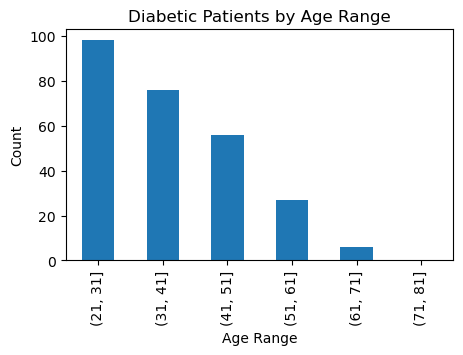

Age
(21, 31]    98
(31, 41]    76
(41, 51]    56
(51, 61]    27
(61, 71]     6
(71, 81]     0
dtype: int64


In [24]:
count = ta.diabetes_by_age()


plt.figure(figsize=(5,3))
count.plot(kind="bar")
plt.title("Diabetic Patients by Age Range")
plt.xlabel("Age Range")
plt.ylabel("Count")
plt.show()

print(count)

***Conclusion of Target Analysis***
1. there is can 85% of diabetes patients remaining are nondiabetes patients
2. age range between 21-31 having more number of diabetes

**Univariate Analysis**

skewness is : 0.9016739791518588


<Figure size 600x400 with 0 Axes>

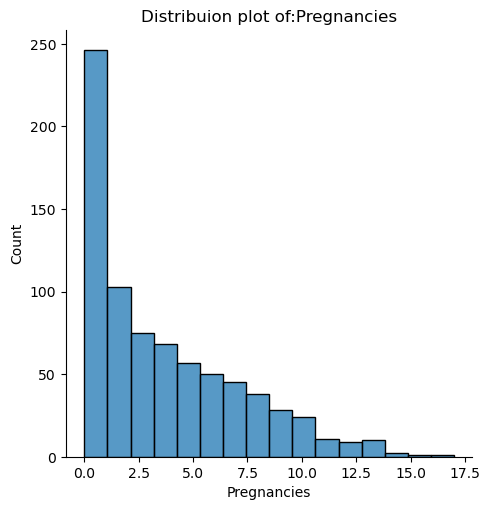

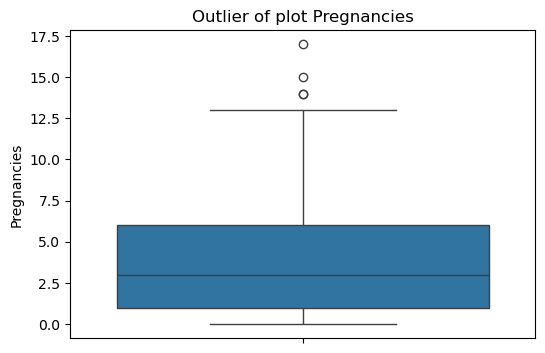

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64

In [26]:
import univariate_analysis as ua
importlib.reload(ua)

# col : Pregnancies
uni_Pregnancies = ua.Univariate_Analysis(df,'Pregnancies')


uni_Pregnancies.dist_plot()
uni_Pregnancies.outlier()
uni_Pregnancies.describe()

***Conclusion***
1. 240+ patients is having no 'Pregnancies'
2. there is a 3three outliers in this col:'Pregnancies'
3. data distribution is right skewed

skewness is : 0.5332247526703329


<Figure size 600x400 with 0 Axes>

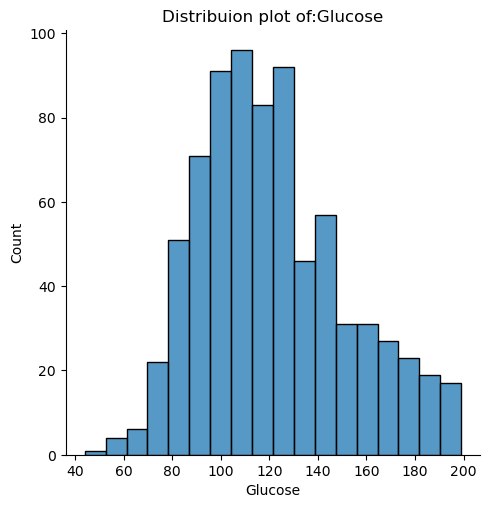

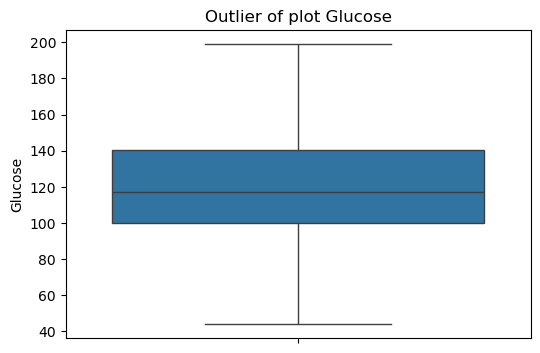

count    768.000000
mean     121.681605
std       30.436016
min       44.000000
25%       99.750000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

In [27]:
# col : Glucose 
uni_glucose = ua.Univariate_Analysis(df,'Glucose')


uni_glucose.dist_plot()
uni_glucose.outlier()
uni_glucose.describe()

In [28]:
cnt = df[(df['Glucose'] >=75) & (df['Glucose'] <=120)]

print(len(cnt))

391


***conclusion***
1. the data distribuion is almost normal 
2. there is only 1 outlier and also it is not affecting the distribution because it value is '0'
3. out of 768 patients 391 patients is having glucose level range between 75-120

skewness is : 0.17305021322096162


<Figure size 600x400 with 0 Axes>

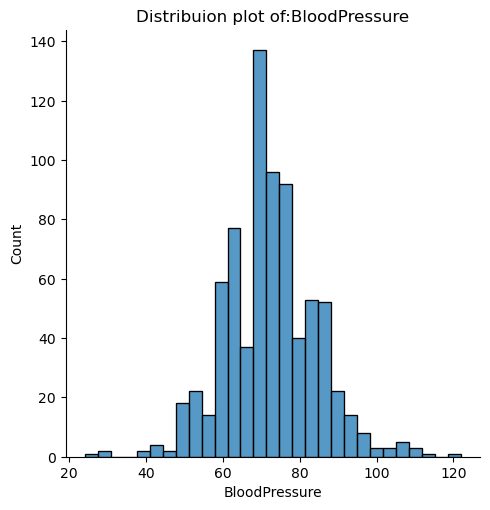

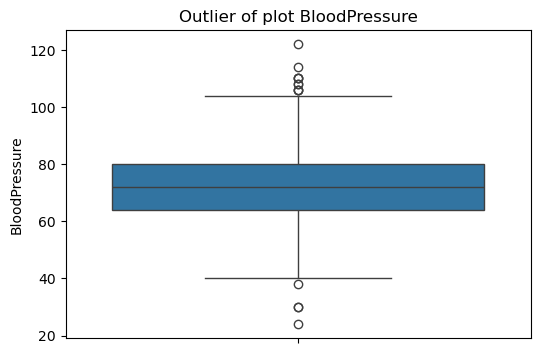

count    768.000000
mean      72.254807
std       12.115932
min       24.000000
25%       64.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

In [29]:
# col : BloodPressure
uni_bp = ua.Univariate_Analysis(df,'BloodPressure')

uni_bp.dist_plot()
uni_bp.outlier()
uni_bp.describe()

***conclusion***
1. we need to remove outlier to get a normal distribuion 
2. there is a both side outlier is detected
3. average range is bp is 60-80

skewness is : 2.1516455800792156


<Figure size 600x400 with 0 Axes>

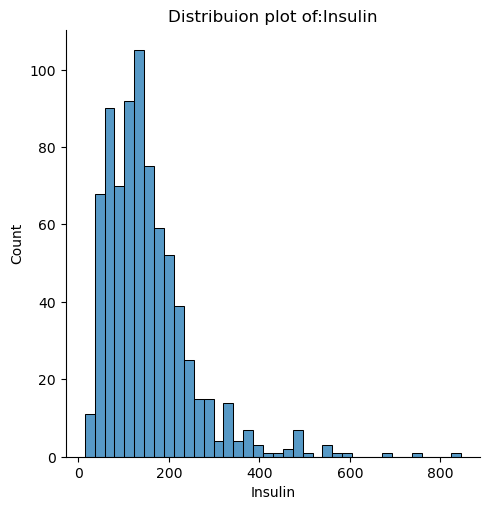

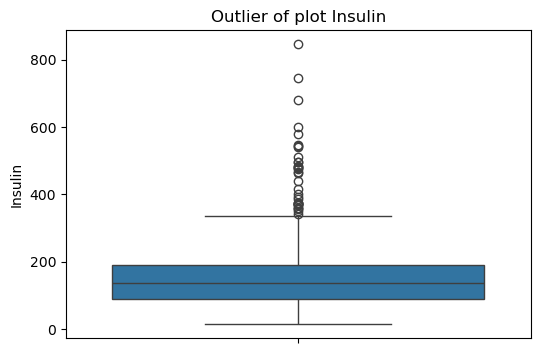

count    768.000000
mean     153.859115
std       98.360613
min       14.000000
25%       88.750000
50%      135.000000
75%      190.000000
max      846.000000
Name: Insulin, dtype: float64

In [30]:
#column : Insulin

uni_insulin = ua.Univariate_Analysis(df,'Insulin')

uni_insulin.dist_plot()
uni_insulin.outlier()
uni_insulin.describe()

In [31]:
# cross check

Insulin_high = df[(df['Insulin'] >=127) & (df['Outcome']==1)]
Insulin_low = df[(df['Insulin'] <=79) & (df['Outcome']==1)]

print('high insulin diabetes patient percenatage:',(Insulin_high.shape[0] / 657)*100) #657 number of diabetes
print('low insluin diabetes patient percentage',(Insulin_low.shape[0] / 657)*100) 

high insulin diabetes patient percenatage: 32.115677321156774
low insluin diabetes patient percentage 1.67427701674277


***conclusion***
1. high insulini raises the biabetes!
2. low insulin patients is having an diabetes 22%
3. 350+ level insulin is considered as outliers 

skewness is : 0.6011031773105561


<Figure size 600x400 with 0 Axes>

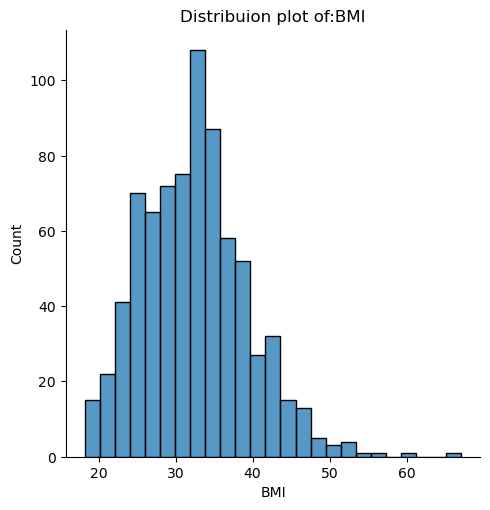

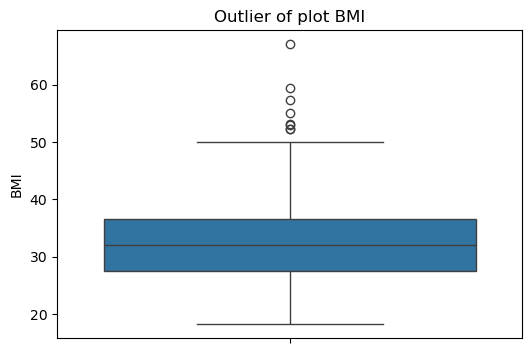

count    768.000000
mean      32.450805
std        6.875374
min       18.200000
25%       27.500000
50%       32.000000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

In [32]:
# col : BMI
uni_bmi = ua.Univariate_Analysis(df,'BMI')


uni_bmi.dist_plot()
uni_bmi.outlier()
uni_bmi.describe()


***conclusion***: ***bmi***
1. outlier detected , but it will be normal distribution if we removed the outliers
2. most of the outliers find in righ skew
3. average bmi range between 20-30

skewness is : 1.1295967011444805


<Figure size 600x400 with 0 Axes>

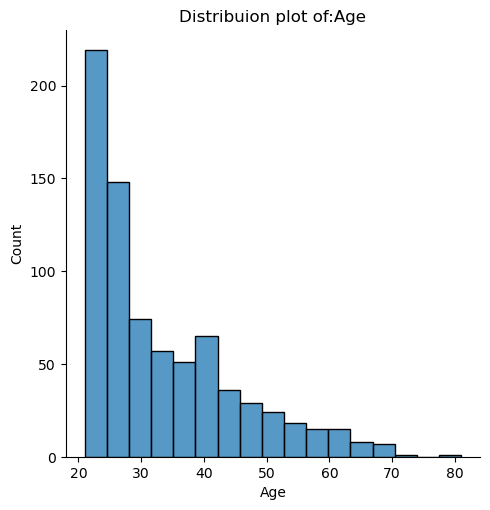

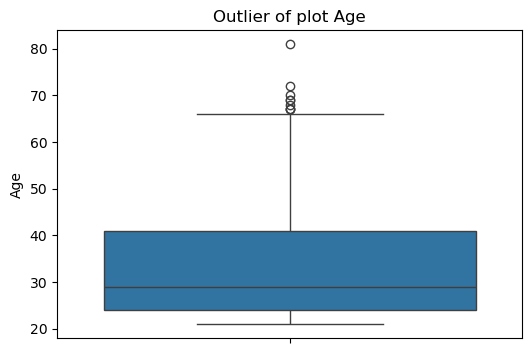

count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64

In [33]:
# age

uni_age = ua.Univariate_Analysis(df,'Age')

uni_age.dist_plot()
uni_age.outlier()
uni_age.describe()

***conclusion***: ***age***
1. right skewed distribuion 
2. age range of 20-33 facing high number of biabetes
3. age range 65+ are considered as outliers


Bivariate Analysis


In [34]:
import biavariate_analysis
importlib.reload(biavariate_analysis)

ba = biavariate_analysis.Bivariate_Analysis(df)

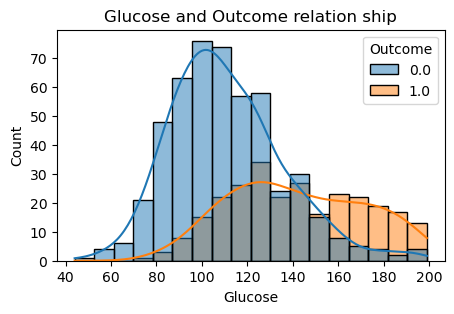

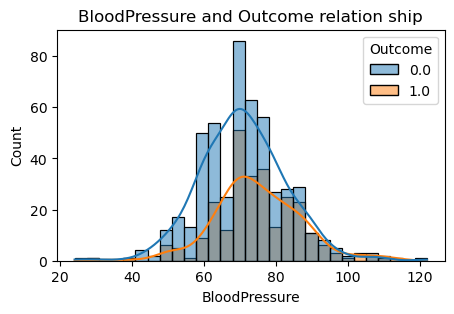

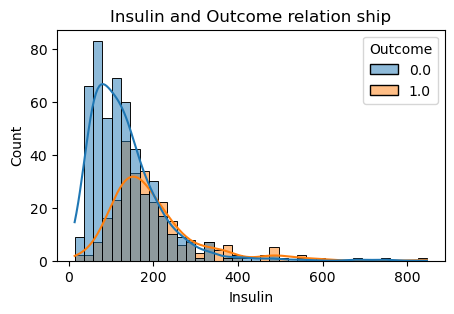

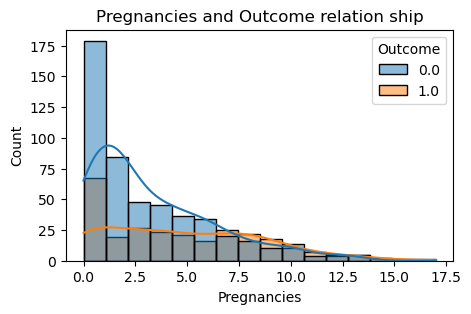

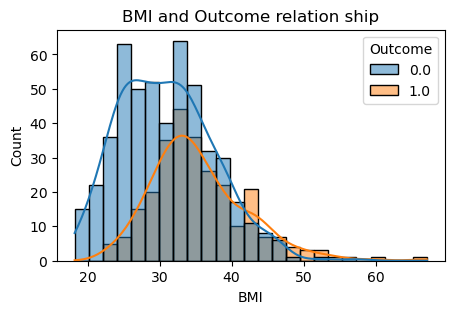

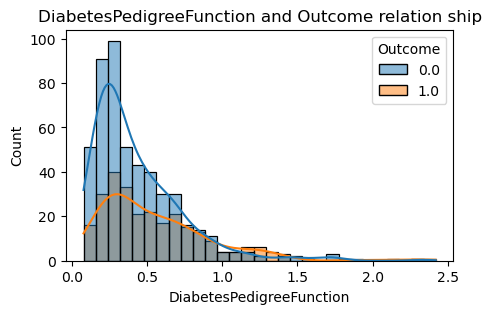

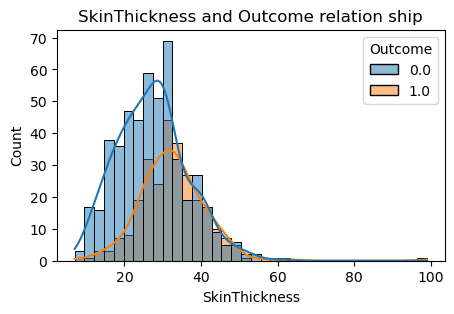

In [35]:
col = ['Glucose','BloodPressure','Insulin','Pregnancies','BMI','DiabetesPedigreeFunction','SkinThickness']

for i in col:
    ba.corr(i,'Outcome')

**Glucose** : are rarely affecting , we want to cross check with another correlation with this for final conclude.

**BMI** : are second highest which also affecting the patient, **Blood Presure** is rarely effecting the patient and also be , this is not an final,we want to process with multivariate analysis **

**!**:in this data set we can't conculde which one particular feature is only effecting the patients there are several features inculde patient is facing an diabetes

Multivariate Analysis

In [36]:
import multivariate_analysis

ma = multivariate_analysis.Multivariate_Analysis(df)

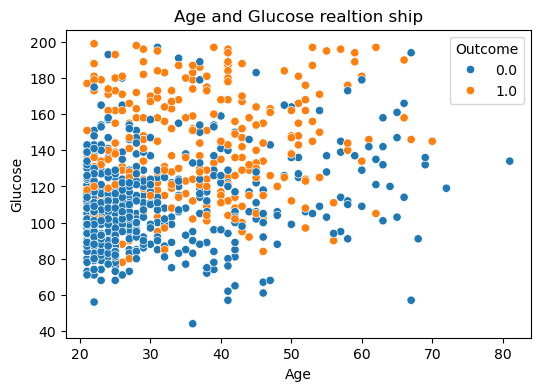

age btw 20 to 45 ranges are highly facing diabetes


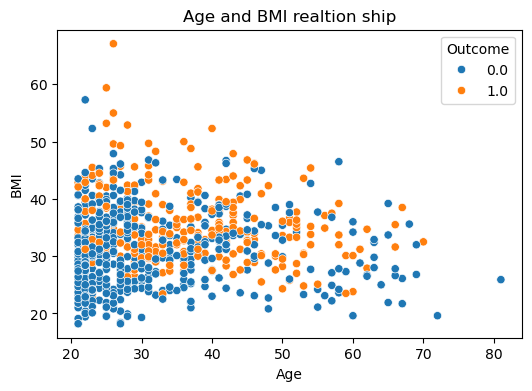

in the BMI range 25-45 raising the diabetes


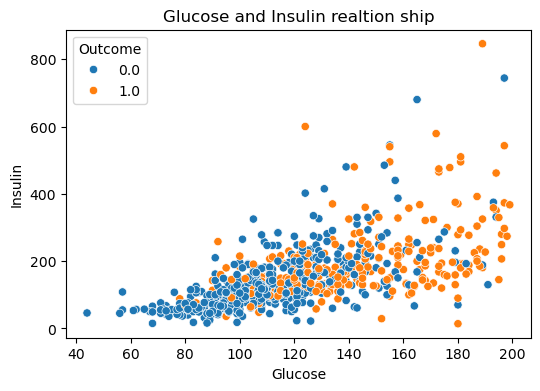

Diabetic patients generally have higher glucose levels than non-diabetic patients.


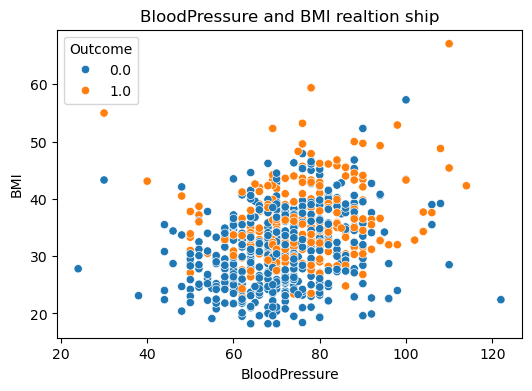

bmi range 28-50 are raising with blood presure range between 60-95


In [37]:
age_glucose = ma.pairplot('Age','Glucose','Outcome')
print('age btw 20 to 45 ranges are highly facing diabetes')
bmi_age = ma.pairplot('Age','BMI','Outcome')
print('in the BMI range 25-45 raising the diabetes')
glucose_insulin = ma.pairplot('Glucose','Insulin','Outcome')
print('Diabetic patients generally have higher glucose levels than non-diabetic patients.')
blood_bmi = ma.pairplot('BloodPressure','BMI','Outcome')
print('bmi range 28-50 are raising with blood presure range between 60-95')

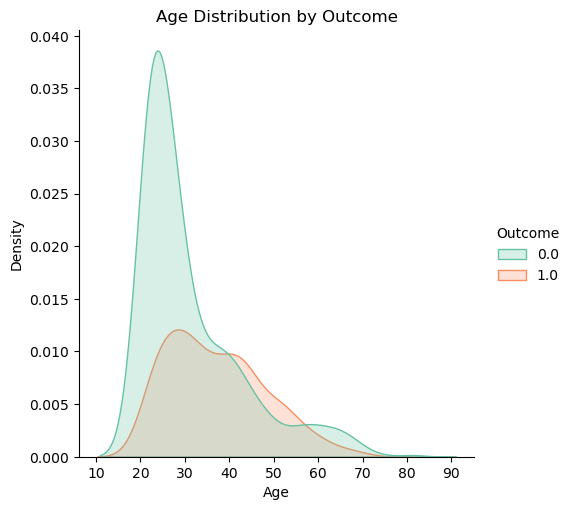

In [40]:
# 

# Compares the distribution of Age for Outcome 0 vs Outcome 1
sns.displot(data=df, x='Age', hue='Outcome', kind='kde', fill=True, palette='Set2')

plt.title('Age Distribution by Outcome')
plt.xlabel('Age')
plt.show()


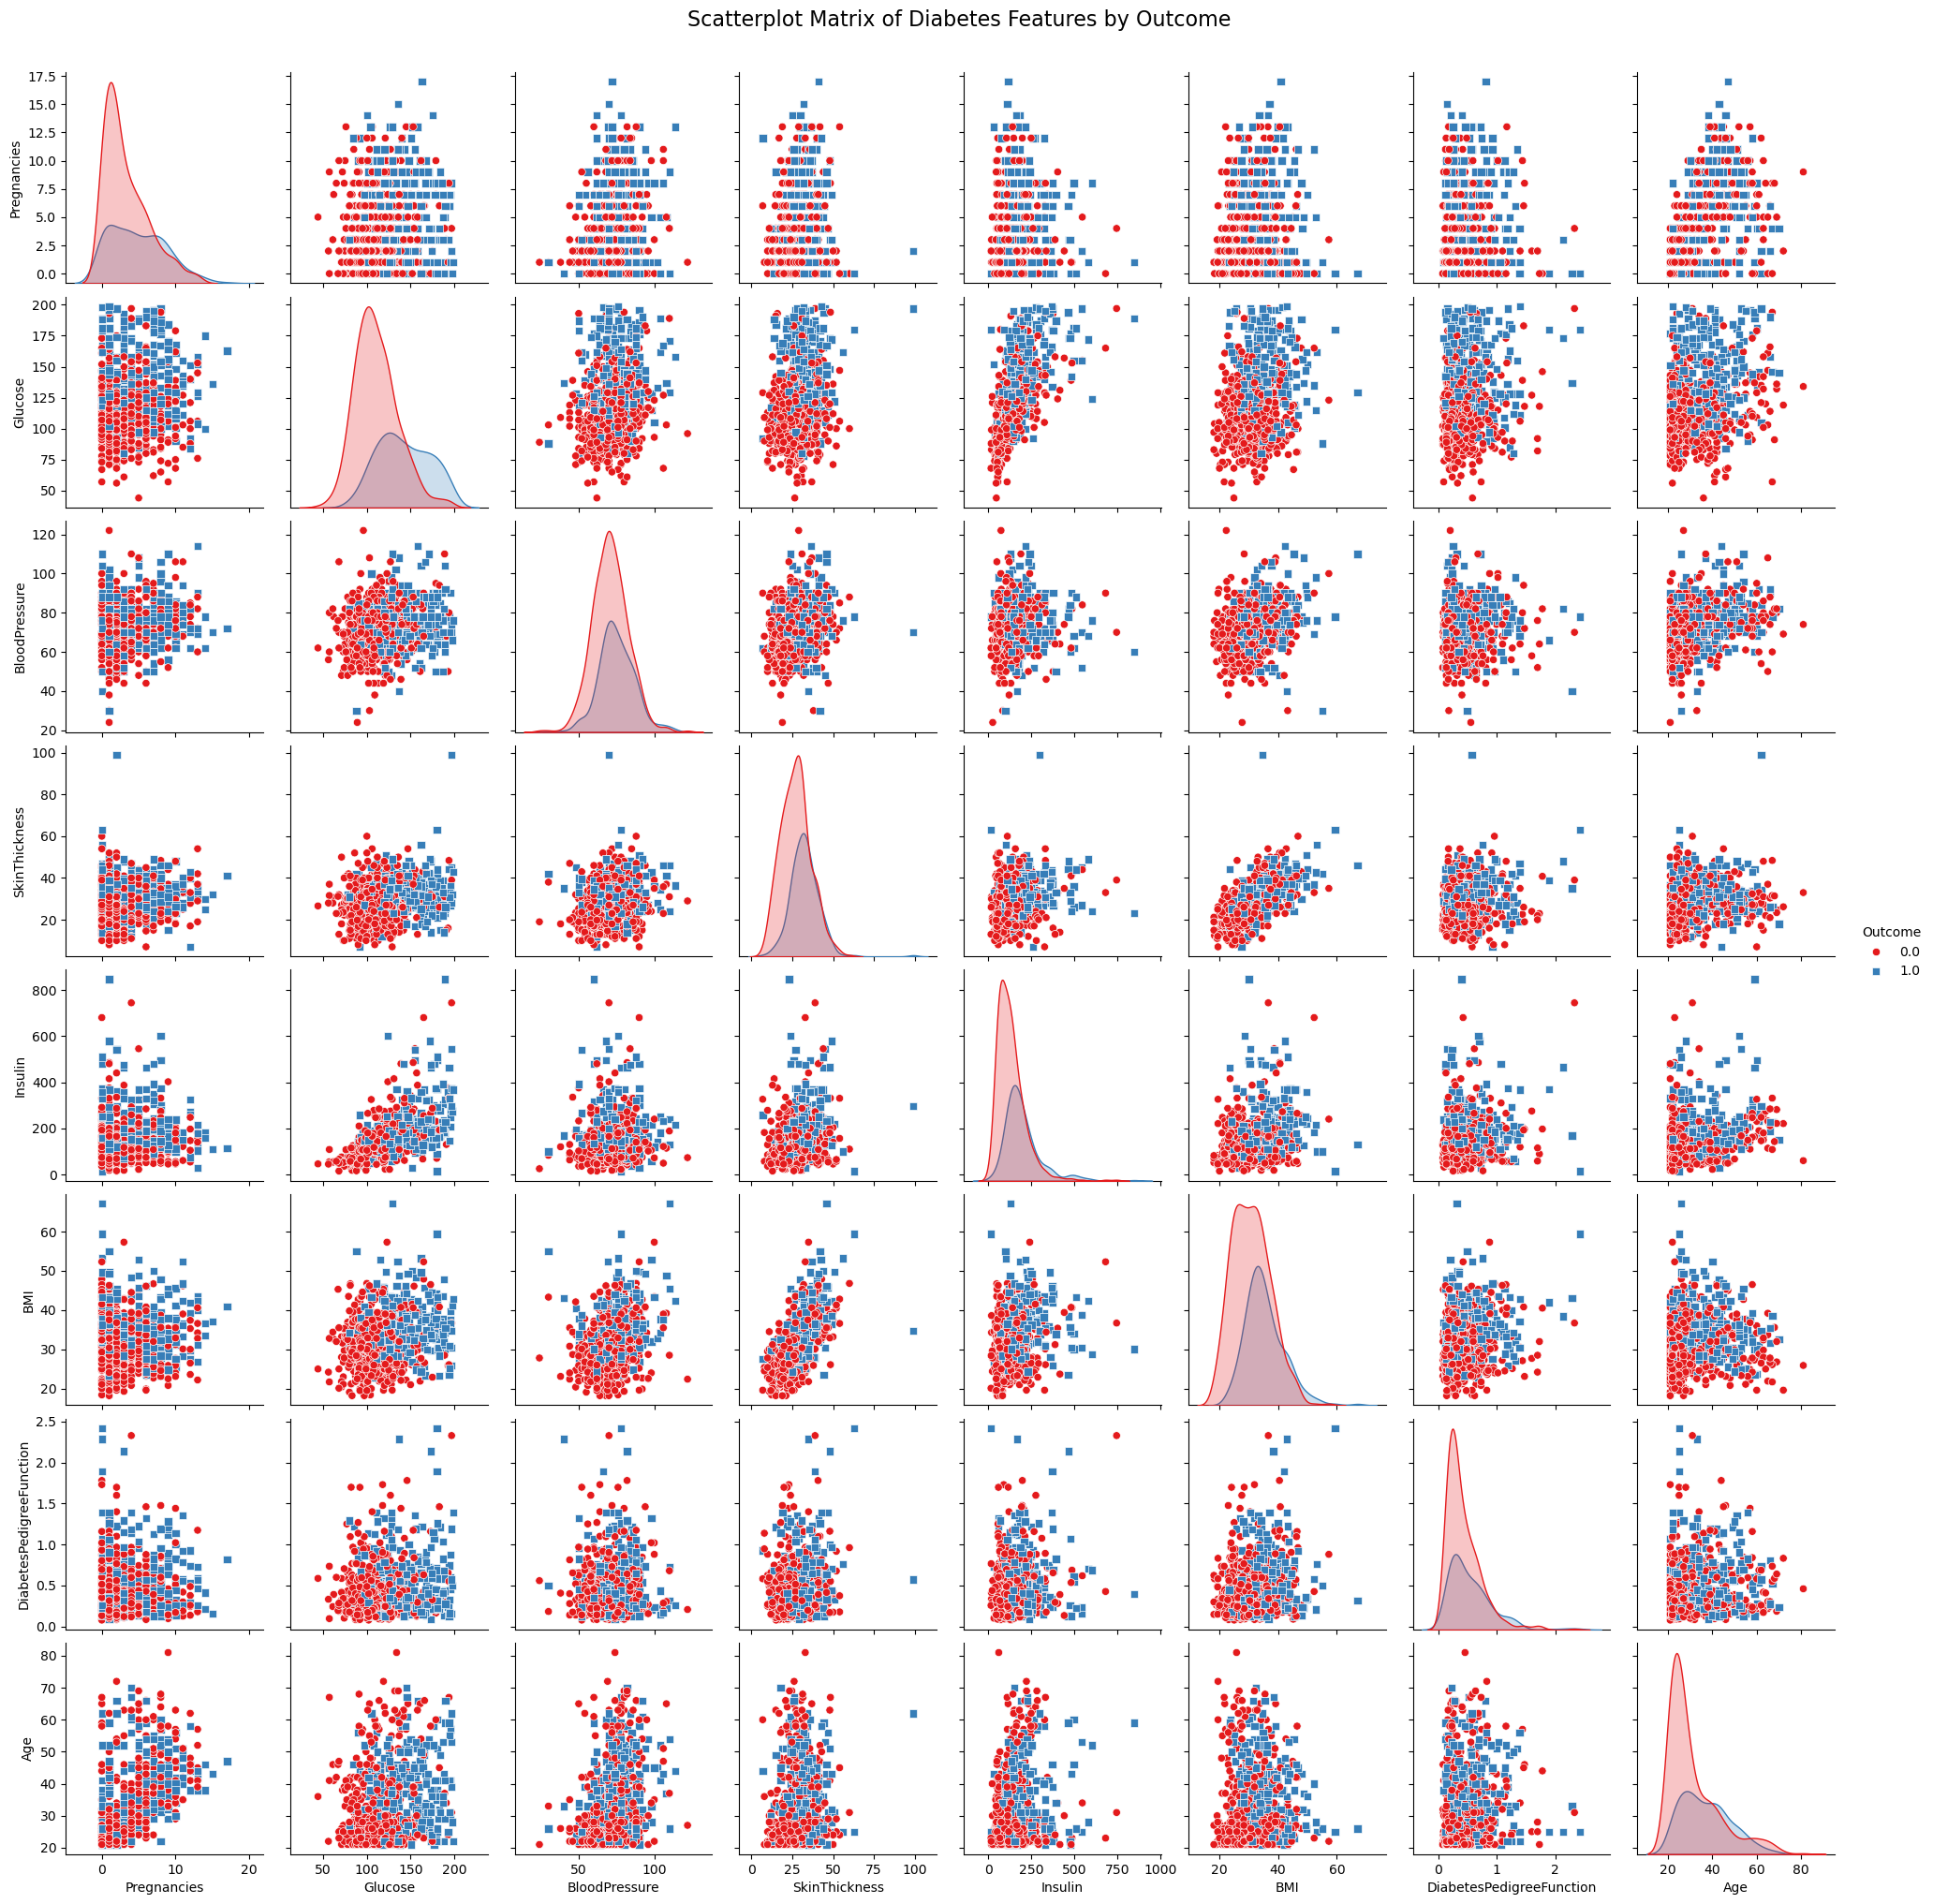

In [4]:
diabetes_plot = sns.pairplot(
    data=df, hue="Outcome", palette="Set1", diag_kind="kde", markers=["o", "s"]
)

# 3. Adjust layout to prevent text crowding
diabetes_plot.fig.suptitle(
    "Scatterplot Matrix of Diabetes Features by Outcome", y=1.02, fontsize=16
)

# 4. Display the graph
plt.show()